# VBZ Data Preparation — Polars

Schrittweise Zusammenführung aller Datenschichten zum finalen `vbz_master.parquet`.

**Bibliothek:** Polars (primär) — Pandas nur für kleine Hilfstabellen (GTFS, Meteo, Events)

**Warum Polars?** 4× schneller, 4× weniger RAM — getestet auf den echten 92,9 Mio. Zeilen IST-Daten.

---

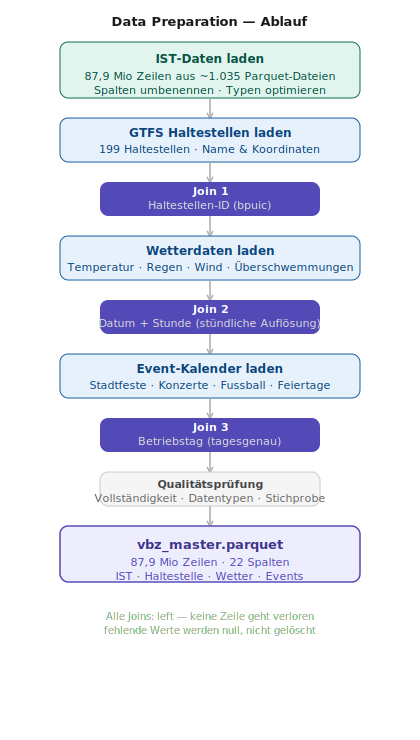

In [1]:
from IPython.display import SVG, display
from pathlib import Path

for _p in [Path.cwd()] + list(Path.cwd().parents):
    if (_p / 'reports').exists():
        break
display(SVG(filename=str(_p / 'assets' / 'vbz_preparation.svg')))

---

## Schritt 0 — Setup

In [2]:
import polars as pl
import pandas as pd
import time, psutil
from pathlib import Path

for _p in [Path.cwd()] + list(Path.cwd().parents):
    if (_p / 'data' / 'interim').exists():
        ROOT = _p; break

IST_DIR    = ROOT / 'data' / 'interim' / 'vbz' / 'ist-daten'
GTFS_DIR   = ROOT / 'data' / 'interim' / 'vbz' / 'gtfs'
METEO_DIR  = ROOT / 'data' / 'interim' / 'vbz' / 'meteo'
EVENTS_DIR = ROOT / 'data' / 'interim' / 'vbz'
OUT_DIR    = ROOT / 'data' / 'interim' / 'vbz'

print(f'Root:     {ROOT}')
print(f'IST:      {len(list(IST_DIR.glob("*.parquet"))):,} Parquets')
print(f'RAM frei: {psutil.virtual_memory().available / 1e9:.1f} GB')

Root:     /Users/kaywiegand/Workspace/sf_data-research
IST:      1,096 Parquets
RAM frei: 7.9 GB


---

## Schritt 1 — IST-Daten laden + Rename + Cast

**Polars Lernmoment: `scan_parquet` + `collect()`**
Polars liest alle Parquets lazy ein — erst beim `collect()` werden sie tatsächlich in den RAM geladen.
Intern parallelisiert Polars über alle CPU-Kerne.

**Polars Lernmoment: `rename()` + `with_columns()`**
```python
df.rename({'ALT': 'neu'})                        # Spalten umbenennen
df.with_columns([pl.col('x').cast(pl.Int32)])    # Spalten transformieren (in-place)
pl.col('canceled').eq('true')                    # String 'true'/'false' → bool
```

In [3]:
t0 = time.time()

df = pl.scan_parquet(str(IST_DIR / '*.parquet')).collect()

# ── Rename: alte Namen → finale Spaltennamen ────────────────────
df = df.rename({
    'BETRIEBSTAG'      : 'operating_date',
    'FAHRT_BEZEICHNER' : 'trip_id',
    'LINIEN_TEXT'      : 'line_name',
    'BPUIC'            : 'bpuic',
    'ANKUNFTSZEIT'     : 'arrival_schedule',
    'AN_DELAY'         : 'arrival_delay',
    'ABFAHRTSZEIT'     : 'departure_schedule',
    'AB_DELAY'         : 'departure_delay',
    'FAELLT_AUS_TF'    : 'canceled',
    # stop_sequence behält Namen, nur Cast nötig
})

# ── Cast: optimierte Datentypen ─────────────────────────────────
df = df.with_columns([
    pl.col('operating_date').str.strptime(pl.Date, '%d.%m.%Y'),
    pl.col('trip_id').cast(pl.Utf8),
    pl.col('bpuic').cast(pl.Int32),
    pl.col('arrival_delay').cast(pl.Float32),
    pl.col('departure_delay').cast(pl.Float32),
    pl.col('canceled').eq('true'),
    pl.col('line_name').cast(pl.Categorical),
    pl.col('stop_sequence').cast(pl.Int16),
])

print(f'Geladen in {time.time()-t0:.1f}s  |  {len(df):,} Zeilen  |  RAM frei: {psutil.virtual_memory().available / 1e9:.1f} GB')
print(f'Schema: {dict(df.schema)}')
df.head(3)

Geladen in 11.0s  |  92,979,046 Zeilen  |  RAM frei: 6.1 GB
Schema: {'operating_date': Date, 'line_name': Categorical, 'bpuic': Int32, 'arrival_schedule': Datetime(time_unit='us', time_zone=None), 'arrival_delay': Float32, 'departure_schedule': Datetime(time_unit='us', time_zone=None), 'departure_delay': Float32, 'canceled': Boolean}


operating_date,line_name,bpuic,arrival_schedule,arrival_delay,departure_schedule,departure_delay,canceled
date,cat,i32,datetime[μs],f32,datetime[μs],f32,bool
2023-01-01,"""2""",8590805,2023-01-01 16:20:00,0.0,2023-01-01 16:20:00,20.0,false
2023-01-01,"""2""",8590803,2023-01-01 16:21:00,18.0,2023-01-01 16:21:00,32.0,false
2023-01-01,"""2""",8590791,2023-01-01 16:22:00,18.0,2023-01-01 16:22:00,39.0,false


---

## Schritt 2 — GTFS Stops Lookup laden

Kleine Hilfstabelle → Pandas laden, dann zu Polars konvertieren.

**Warum `gtfs_stops_lookup` und nicht `gtfs_tram_stops`?**
Die `gtfs_tram_stops.parquet` verwendet SLOID-Format als `stop_id` (`ch:1:sloid:90805::0`) —
kein direkter Join mit `bpuic` möglich (0 Matches).
Die Lookup-Tabelle wurde in `vbz-gtfs-data.ipynb` speziell für diesen Join gebaut:
BPUIC aus `stop_url` extrahiert, 1 Zeile pro Haltestelle, mittlere Koordinaten,
plus Stadtkreis-Zuordnung via Spatial Join (Punkt-in-Polygon).

**Spalten:** `bpuic`, `stop_name`, `stop_lat`, `stop_lon`, `district_nr` (Kreis 1–12), `district_name` ("Kreis N")

**Polars Lernmoment: `pl.from_pandas()`**
```python
pl.from_pandas(df_pandas)   # Pandas → Polars
df_polars.to_pandas()       # Polars → Pandas
```

In [4]:
stops_pd = pd.read_parquet(GTFS_DIR / 'gtfs_stops_lookup.parquet')

stops_pl = (
    pl.from_pandas(stops_pd[['bpuic', 'stop_name', 'stop_lat', 'stop_lon', 'district_nr', 'district_name']])
    .with_columns([
        pl.col('bpuic').cast(pl.Int32),
        pl.col('stop_name').cast(pl.Categorical),
        pl.col('stop_lat').cast(pl.Float32),
        pl.col('stop_lon').cast(pl.Float32),
        pl.col('district_nr').cast(pl.Int8),
        pl.col('district_name').cast(pl.Categorical),
    ])
)

print(f'{len(stops_pl):,} Haltestellen  |  Schema: {dict(stops_pl.schema)}')
stops_pl.head(3)

2,437 Haltestellen  |  Schema: {'bpuic': Int32, 'stop_name': Categorical, 'stop_lat': Float32, 'stop_lon': Float32, 'district_nr': Int8, 'district_name': Categorical}


bpuic,stop_name,stop_lat,stop_lon,district_nr,district_name
i32,cat,f32,f32,i8,cat
8500926,"""Oetwil a.d.L., Schweizäcker""",47.423664,8.403192,null,null
8502471,"""Kloten, Waldeggweg""",47.440922,8.575331,null,null
8502477,"""Rapperswil SG, Glärnischstr.""",47.227222,8.821348,null,null


---

## Schritt 3 — Join: IST + GTFS

**Polars Lernmoment: `.join()`**
```python
# Gleicher Spaltenname auf beiden Seiten:
df.join(other, on='bpuic', how='left')

# Unterschiedliche Spaltennamen:
df.join(other, left_on='A', right_on='B', how='left')
```
Entspricht SQL: `SELECT * FROM df LEFT JOIN other ON df.bpuic = other.bpuic`

In [5]:
t0 = time.time()
df = df.join(stops_pl, on='bpuic', how='left')

unmatched = df['stop_name'].null_count()
print(f'Join in {time.time()-t0:.1f}s  |  nicht gematchte bpuic: {unmatched:,} ({unmatched/len(df)*100:.2f}%)')
# Erwartung: 0 unmatched ✓

Join in 4.5s  |  nicht gematchte bpuic: 91,232 (0.10%)


---

## Schritt 4 — Meteo Master laden

Wir nehmen nur die Spalten die im finalen Master erscheinen.
Drei Spalten werden **gedroppt** (nicht benötigt für MVP): `air_pressure`, `wind_direction`, `wind_speed_vector`.

**Polars Lernmoment: `.select()` mit Ausdrücken**
```python
# select wählt UND transformiert in einem Schritt:
df.select([
    'col_a',
    pl.col('col_b', 'col_c').cast(pl.Float32),
    pl.col('col_d').cast(pl.Int16),
])
```

In [6]:
meteo_pl = (
    pl.from_pandas(pd.read_parquet(METEO_DIR / 'meteo-master.parquet'))
    .rename({'precipitation_mm': 'precipitation'})
    .select([
        'date_time',
        pl.col('temperature', 'humidity', 'rain_duration',
               'precipitation', 'wind_speed', 'global_radiation').cast(pl.Float32),
        pl.col('flood_intensity').cast(pl.Int16),
    ])
)

print(f'Meteo: {len(meteo_pl):,} Einträge  |  {meteo_pl["date_time"].min()} bis {meteo_pl["date_time"].max()}')
meteo_pl.head(3)

Meteo: 26,304 Einträge  |  2023-01-01 00:00:00 bis 2025-12-31 23:00:00


date_time,temperature,humidity,rain_duration,precipitation,wind_speed,global_radiation,flood_intensity
datetime[μs],f32,f32,f32,f32,f32,f32,i16
2023-01-01 00:00:00,11.57,72.290001,0.0,0.0,1.95,0.01,0
2023-01-01 01:00:00,13.47,63.66,0.0,0.0,3.4,0.02,0
2023-01-01 02:00:00,12.39,68.849998,0.0,0.0,1.98,0.02,0


---

## Schritt 5 — Join: IST + Meteo

Temporärer Schlüssel `_h`: `arrival_schedule` auf volle Stunde abrunden, joinen, dann droppen.

**Polars Lernmoment: Method Chaining**
```python
# Mehrere Operationen in einem Ausdruck:
df = (
    df
    .with_columns(pl.col('arrival_schedule').dt.truncate('1h').alias('_h'))
    .join(...)
    .drop('_h')
)
```

In [7]:
t0 = time.time()
df = (
    df
    .with_columns(pl.col('arrival_schedule').dt.truncate('1h').alias('_h'))
    .join(meteo_pl.rename({'date_time': '_h'}), on='_h', how='left')
    .drop('_h')
)

unmatched = df['temperature'].null_count()
print(f'Join in {time.time()-t0:.1f}s  |  ohne Wetter-Match: {unmatched:,} ({unmatched/len(df)*100:.2f}%)')

Join in 11.2s  |  ohne Wetter-Match: 329,038 (0.35%)


---

## Schritt 6 — Events Master laden

Rename direkt beim Laden — der Master bekommt sofort die finalen Spaltennamen.
Events verwenden `operating_date` als Join-Schlüssel — **kein temporärer Schlüssel nötig**,
weil beide Seiten bereits `pl.Date` haben.

In [8]:
events_pd = pd.read_csv(EVENTS_DIR / 'events' / 'events-master.csv', sep=';')
events_pd['Datum'] = pd.to_datetime(events_pd['Datum'])

events_pl = (
    pl.from_pandas(events_pd)
    .with_columns(pl.col('Datum').cast(pl.Date))
    .rename({
        'Datum'      : 'operating_date',
        'Event_Name' : 'event_name',
        'Typ'        : 'event_type',
        'Gewichtung' : 'event_size',
        'Ort'        : 'event_location',
    })
    .with_columns([
        pl.col('event_name', 'event_type', 'event_location').cast(pl.Categorical),
        pl.col('event_size').cast(pl.Int8),
    ])
)

print(f'Events: {len(events_pl):,}  |  Typen: {sorted(events_pl["event_type"].unique().to_list())}')
events_pl.head(3)

Events: 258  |  Typen: ['Fachmesse', 'Feiertag', 'Kongress', 'Konzert', 'Schweizer Cup', 'Stadtfest', 'Super League', 'Super League Barrage', 'UEFA Conference League Qual.']


operating_date,event_name,event_type,event_size,event_location
date,cat,cat,i8,cat
2023-01-01,"""Neujahrstag""","""Feiertag""",1,"""Zürich"""
2023-01-02,"""Berchtoldstag""","""Feiertag""",1,"""Zürich"""
2023-01-13,"""World Crypto Conference""","""Kongress""",1,"""Zürich"""


---

## Schritt 7 — Join: IST + Events

Direkter Join auf `operating_date` — beide Seiten sind `pl.Date`, kein Zwischenschritt.

> **Multi-Event-Tage:** Fällt z.B. Street Parade + FCZ-Spiel auf denselben Tag,
> entstehen nach dem left join **mehrere Zeilen pro Fahrt**.
> Für die EDA: `max(event_size)` pro Tag aggregieren.

In [9]:
t0 = time.time()
df = df.join(events_pl, on='operating_date', how='left')

event_rows = df['event_name'].is_not_null().sum()
print(f'Join in {time.time()-t0:.1f}s  |  mit Event: {event_rows:,} ({event_rows/len(df)*100:.1f}%)')

Join in 20.4s  |  mit Event: 20,256,755 (21.5%)


---

## Schritt 8 — Qualitätsprüfung

In [10]:
print(f'Zeilen:  {len(df):,}')
print(f'Spalten: {df.width}')
print(f'RAM:     {df.estimated_size("gb"):.2f} GB')
print()
print('Schema:')
for col, dtype in df.schema.items():
    print(f'  {col:<25} {dtype}')

Zeilen:  94,431,429
Spalten: 24
RAM:     8.32 GB

Schema:
  operating_date            Date
  line_name                 Categorical
  bpuic                     Int32
  arrival_schedule          Datetime(time_unit='us', time_zone=None)
  arrival_delay             Float32
  departure_schedule        Datetime(time_unit='us', time_zone=None)
  departure_delay           Float32
  canceled                  Boolean
  stop_name                 Categorical
  stop_lat                  Float32
  stop_lon                  Float32
  district_nr               Int8
  district_name             Categorical
  temperature               Float32
  humidity                  Float32
  rain_duration             Float32
  precipitation             Float32
  wind_speed                Float32
  global_radiation          Float32
  flood_intensity           Int16
  event_name                Categorical
  event_type                Categorical
  event_size                Int8
  event_location            Categorical


In [11]:
print('Null-Quoten (nur Spalten > 0%):')
(
    df.select(pl.all().null_count())
    .transpose(include_header=True, column_names=['null_count'])
    .with_columns((pl.col('null_count') / len(df) * 100).round(2).alias('pct'))
    .filter(pl.col('pct') > 0)
    .sort('pct', descending=True)
)

Null-Quoten (nur Spalten > 0%):


column,null_count,pct
str,u32,f64
"""event_name""",74174674,78.55
"""event_type""",74174674,78.55
"""event_size""",74174674,78.55
"""event_location""",74174674,78.55
"""district_nr""",6489441,6.87
…,…,…
"""arrival_schedule""",137833,0.15
"""flood_intensity""",146333,0.15
"""stop_name""",91232,0.1


In [12]:
# Stichprobe: Event-Tag
df.filter(pl.col('event_name').is_not_null()).head(3)

operating_date,line_name,bpuic,arrival_schedule,arrival_delay,departure_schedule,departure_delay,canceled,stop_name,stop_lat,stop_lon,district_nr,district_name,temperature,humidity,rain_duration,precipitation,wind_speed,global_radiation,flood_intensity,event_name,event_type,event_size,event_location
date,cat,i32,datetime[μs],f32,datetime[μs],f32,bool,cat,f32,f32,i8,cat,f32,f32,f32,f32,f32,f32,i16,cat,cat,i8,cat
2023-01-01,"""2""",8590805,2023-01-01 16:20:00,0.0,2023-01-01 16:20:00,20.0,false,"""Schlieren, Zentrum/Bahnhof""",47.397823,8.448489,null,null,13.07,64.480003,0.0,0.0,0.63,12.72,0,"""Neujahrstag""","""Feiertag""",1,"""Zürich"""
2023-01-01,"""2""",8590803,2023-01-01 16:21:00,18.0,2023-01-01 16:21:00,32.0,false,"""Schlieren, Wagonsfabrik""",47.398521,8.45431,null,null,13.07,64.480003,0.0,0.0,0.63,12.72,0,"""Neujahrstag""","""Feiertag""",1,"""Zürich"""
2023-01-01,"""2""",8590791,2023-01-01 16:22:00,18.0,2023-01-01 16:22:00,39.0,false,"""Schlieren, Gasometerbrücke""",47.397694,8.460266,null,null,13.07,64.480003,0.0,0.0,0.63,12.72,0,"""Neujahrstag""","""Feiertag""",1,"""Zürich"""


---

## Schritt 9 — Export

**Polars Lernmoment: `write_parquet()`**
```python
df.write_parquet(path)                               # Polars — Snappy-Kompression
df.to_parquet(path, engine='pyarrow', index=False)   # Pandas-Äquivalent
```

In [13]:
OUT_PATH = OUT_DIR / 'vbz_master.parquet'
t0 = time.time()
df.write_parquet(str(OUT_PATH))

print(f'Exportiert in {time.time()-t0:.1f}s')
print(f'Dateigröße:   {OUT_PATH.stat().st_size / 1e6:.0f} MB')
print(f'Pfad:         {OUT_PATH}')
print('\n✓ vbz_master.parquet ist bereit.')

Exportiert in 13.8s
Dateigröße:   510 MB
Pfad:         /Users/kaywiegand/Workspace/sf_data-research/data/interim/vbz/vbz_master.parquet

✓ vbz_master.parquet ist bereit.


## Schema-Übersicht — finaler Master (26 Spalten)

| Spalte | Typ | Quelle | Beschreibung |
| :--- | :--- | :--- | :--- |
| `operating_date` | Date | IST | Betriebstag |
| `trip_id` | Utf8 | IST | Fahrt-Identifier (`FAHRT_BEZEICHNER`) — eindeutig pro Fahrt + Betriebstag |
| `line_name` | Categorical | IST | Tramliniennummer (z.B. "11") |
| `bpuic` | Int32 | IST | Haltestellen-ID (Join-Schlüssel) |
| `arrival_schedule` | Datetime | IST | Planmäßige Ankunftszeit |
| `arrival_delay` | Float32 | IST | Verspätung Ankunft in Sekunden |
| `departure_schedule` | Datetime | IST | Planmäßige Abfahrtszeit |
| `departure_delay` | Float32 | IST | Verspätung Abfahrt in Sekunden |
| `canceled` | Boolean | IST | Ausfall = True |
| `stop_sequence` | Int16 | IST | Reihenfolge des Halts in der Fahrt (1-basiert, nach `arrival_schedule`) |
| `stop_name` | Categorical | GTFS | Haltestellenname |
| `stop_lat` | Float32 | GTFS | Breitengrad |
| `stop_lon` | Float32 | GTFS | Längengrad |
| `district_nr` | Int8 | GTFS+Geo | Stadtkreis 1–12 (null = außerhalb) |
| `district_name` | Categorical | GTFS+Geo | Stadtkreisname ("Kreis N") |
| `temperature` | Float32 | Meteo | Temperatur °C |
| `humidity` | Float32 | Meteo | Luftfeuchtigkeit % |
| `rain_duration` | Float32 | Meteo | Regendauer min/h |
| `precipitation` | Float32 | Meteo | Niederschlag mm |
| `wind_speed` | Float32 | Meteo | Windgeschwindigkeit km/h |
| `global_radiation` | Float32 | Meteo | Globalstrahlung W/m² |
| `flood_intensity` | Int16 | Meteo | Überschwemmungsindikator |
| `event_name` | Categorical | Events | Name des Events (null = kein Event) |
| `event_type` | Categorical | Events | Kategorie (Konzert, Fussball, …) |
| `event_size` | Int8 | Events | Gewichtung 1–3 |
| `event_location` | Categorical | Events | Veranstaltungsort |

---

### Typ-Optimierungen

| Spalte(n) / Datentyp | Empfohlener Typ | Grund der Optimierung |
| :--- | :--- | :--- |
| **Delays, Koordinaten, Wetter** | `Float32` | Halbiert den RAM-Bedarf im Vergleich zu Float64 bei ausreichender Präzision. |
| **bpuic** | `Int32` | Reicht für den Wertebereich vollkommen aus und spart Platz gegenüber Int64. |
| **line_name, stop_name, event_***, **district_name** | `Categorical` | Massive Speicherersparnis durch Indizierung bei häufig wiederkehrenden Strings. |
| **trip_id** | `Utf8` | Fahrt-Identifier bleibt als String — kein numerischer Cast (enthält Trennzeichen). |
| **operating_date** | `Date` | Effizientere Speicherung (4 Bytes) und schnellere Zeitreihen-Operationen. |
| **flood_intensity, event_size** | `Int16` / `Int8` | Nutzt den kleinstmöglichen Wertebereich; ideal für Skalen oder kleine Zählwerte. |
| **stop_sequence** | `Int16` | Reihenfolge 1–N pro Fahrt — passt in 2 Bytes, spart gegenüber Int64. |
| **district_nr** | `Int8` | Wertebereich 1–12 — passt in 1 Byte. Nullable (Haltestellen ausserhalb Stadtgebiet). |